In [1]:
# =========================================
#  CELL 1: Import Required Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import zipfile
import os
import string
from collections import Counter

# Configure visualization aesthetics
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


In [2]:
# =========================================
#  UNZIP DATASET FILE
# =========================================

from zipfile import ZipFile
import os

# Path to your uploaded ZIP file in Colab
zip_path = "/content/twitter_training.csv.zip"

# Directory to extract files into
extract_dir = "/content/"

# Extract the ZIP file
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ File successfully unzipped!")
print("📂 Extracted files:")
os.listdir(extract_dir)


✅ File successfully unzipped!
📂 Extracted files:


['.config',
 'drive',
 'twitter_validation.csv',
 'twitter_training.csv',
 'twitter_training.csv.zip',
 'sample_data']

In [3]:
# =========================================
# CELL 2: Load the Datasets
# =========================================

# My dataset path
train_path = "/content/twitter_training.csv"
valid_path = "/content/twitter_validation.csv"

# Load both datasets
train_df = pd.read_csv(train_path, header=None)
valid_df = pd.read_csv(valid_path, header=None)

print("✅ Datasets loaded successfully!")
print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {valid_df.shape}")


✅ Datasets loaded successfully!
Training data shape: (74682, 4)
Validation data shape: (1000, 4)


In [4]:
# Display sample rows
train_df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       74682 non-null  int64 
 1   1       74682 non-null  object
 2   2       74682 non-null  object
 3   3       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
valid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   int64 
 1   1       1000 non-null   object
 2   2       1000 non-null   object
 3   3       1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB


In [8]:
train_df.shape

(74682, 4)

In [9]:
# =========================================
# CELL 3: Inspect and Rename Columns
# =========================================

# The dataset has no column names by default
train_df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']
valid_df.columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

# Display sample rows
train_df.head()


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [10]:
# =========================================
# CELL 4: Basic Data Cleaning
# =========================================

# Remove missing or empty rows
train_df.dropna(subset=['Tweet', 'Entity', 'Sentiment'], inplace=True)

# Clean text: remove links, mentions, hashtags, special characters
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)      # URLs
    text = re.sub(r'\@\w+|\#', '', text)                     # @mentions, #hashtags
    text = text.lower()                                      # lowercase
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()                 # extra spaces
    return text

train_df['Clean_Tweet'] = train_df['Tweet'].apply(clean_text)

print("✅ Cleaning complete. Sample cleaned tweet:")
print(train_df['Clean_Tweet'].iloc[0])


✅ Cleaning complete. Sample cleaned tweet:
im getting on borderlands and i will murder you all


/tmp/ipython-input-1306853453.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Sentiment', order=train_df['Sentiment'].value_counts().index, palette='Set2')


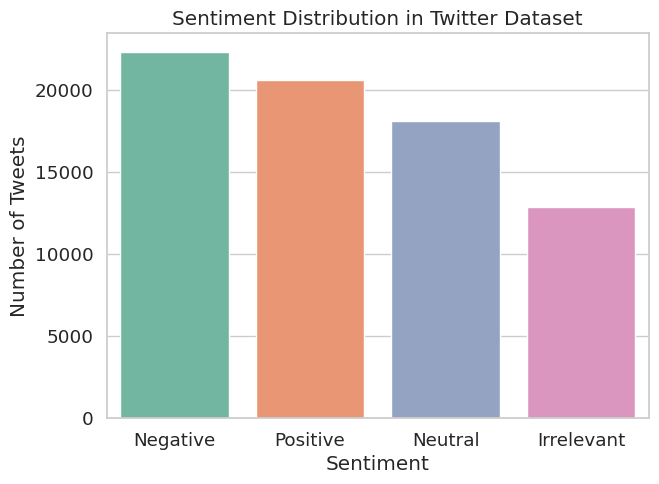

,proportion
Sentiment,
Negative,30.215147
Positive,27.913671
Neutral,24.471593
Irrelevant,17.399589


In [11]:
# =========================================
# CELL 5: Sentiment Distribution
# =========================================

plt.figure(figsize=(7,5))
sns.countplot(data=train_df, x='Sentiment', order=train_df['Sentiment'].value_counts().index, palette='Set2')
plt.title("Sentiment Distribution in Twitter Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

# Display numerical distribution
train_df['Sentiment'].value_counts(normalize=True) * 100


/tmp/ipython-input-982242318.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_entities.values, y=top_entities.index, palette="coolwarm")


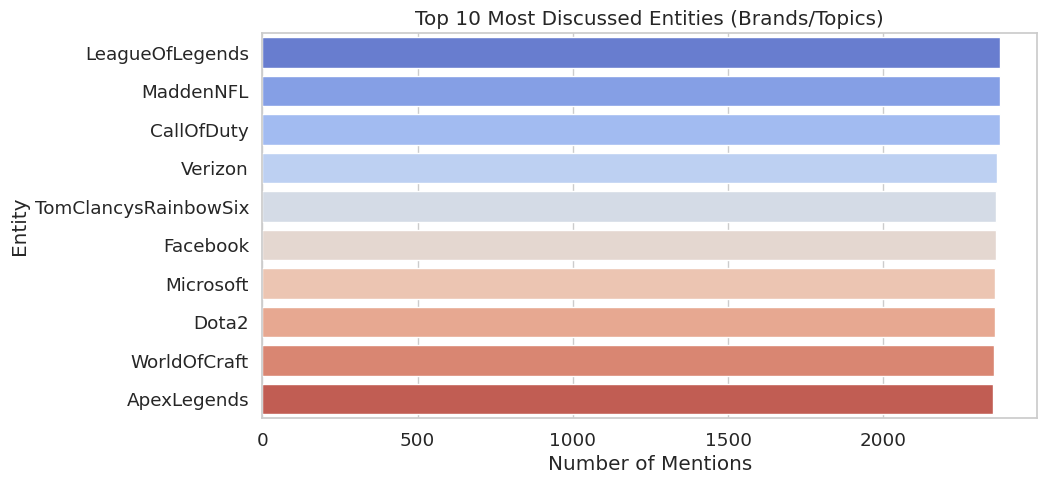

In [12]:
# =========================================
# CELL 6: Entity Frequency Analysis
# =========================================

# Count most discussed entities
top_entities = train_df['Entity'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_entities.values, y=top_entities.index, palette="coolwarm")
plt.title("Top 10 Most Discussed Entities (Brands/Topics)")
plt.xlabel("Number of Mentions")
plt.ylabel("Entity")
plt.show()


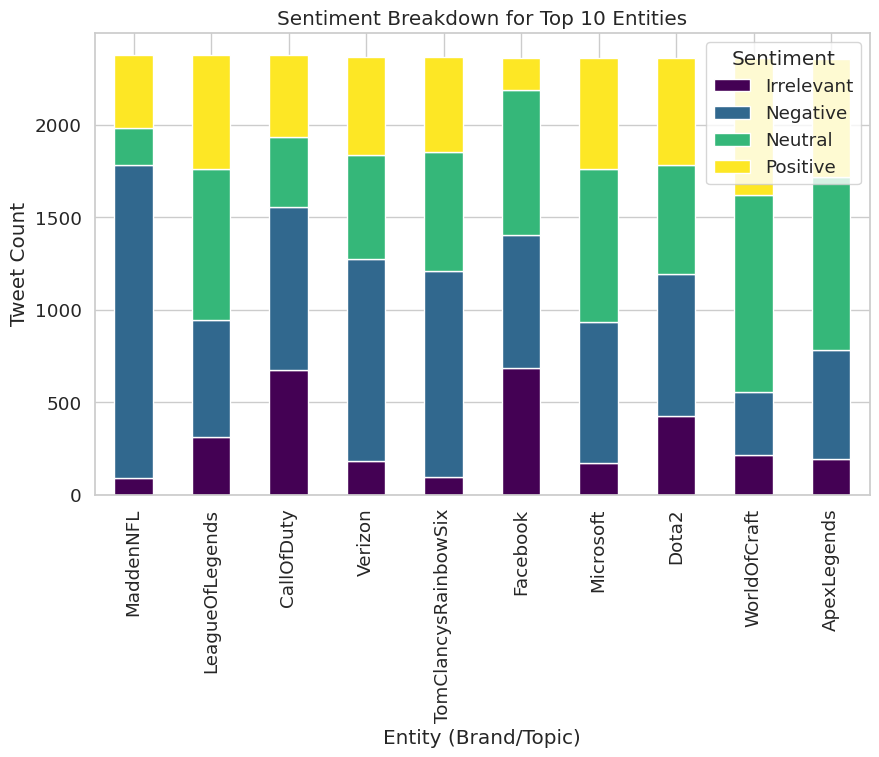

In [13]:
# =========================================
# CELL 7: Entity vs Sentiment Breakdown
# =========================================

# Compute sentiment distribution per entity
entity_sentiment = train_df.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)
entity_sentiment = entity_sentiment.loc[entity_sentiment.sum(axis=1).sort_values(ascending=False).head(10).index]

# Stacked bar plot
entity_sentiment.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title("Sentiment Breakdown for Top 10 Entities")
plt.xlabel("Entity (Brand/Topic)")
plt.ylabel("Tweet Count")
plt.legend(title="Sentiment")
plt.show()


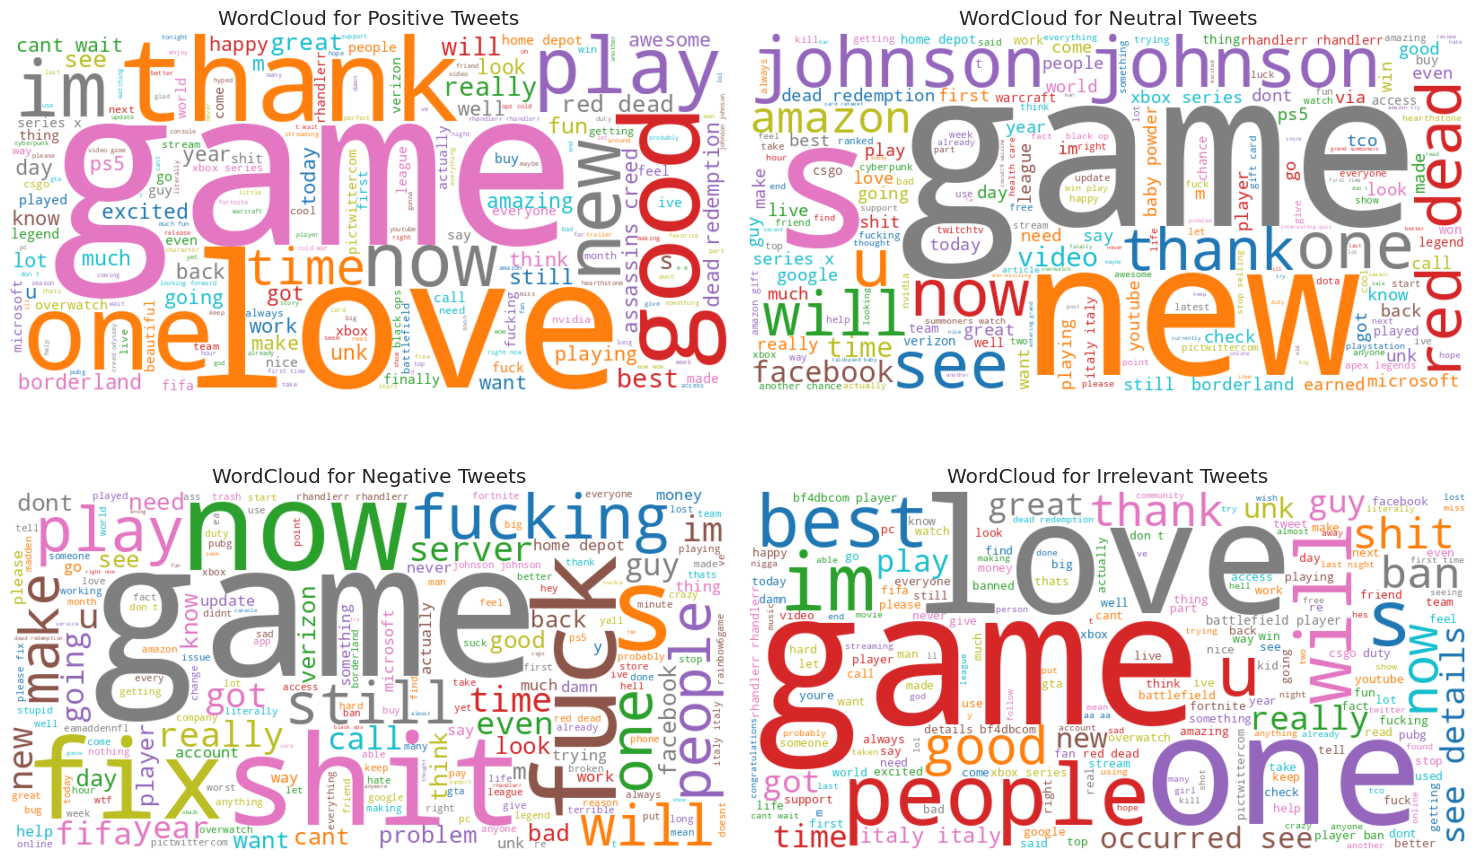

In [14]:
# =========================================
# CELL 8: WordClouds for Each Sentiment
# =========================================

sentiments = train_df['Sentiment'].unique()

plt.figure(figsize=(15,10))
for i, sentiment in enumerate(sentiments):
    plt.subplot(2, 2, i+1)
    text = " ".join(train_df[train_df['Sentiment']==sentiment]['Clean_Tweet'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {sentiment} Tweets")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3143578571.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Bigram', x='Count', data=df_bigrams_pos, palette='Greens_r')


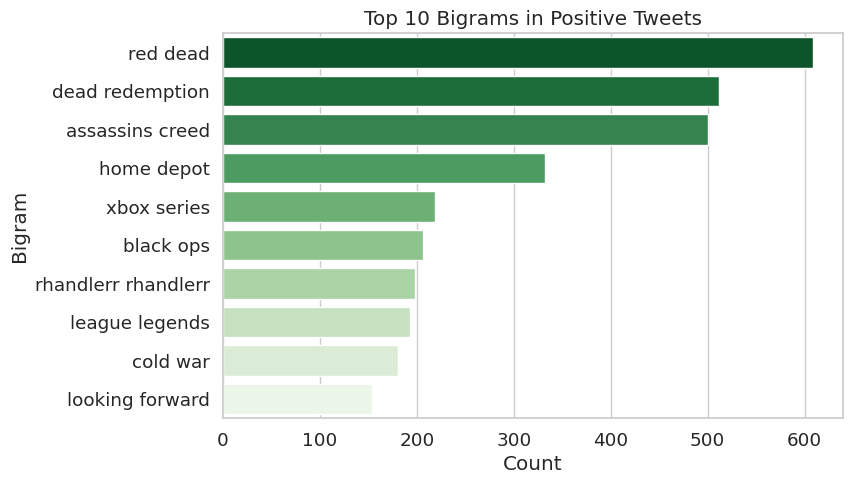

In [15]:
# =========================================
# CELL 9: Common Phrases (Bigram Analysis)
# =========================================

from sklearn.feature_extraction.text import CountVectorizer

# Function to extract n-grams
def get_top_ngrams(corpus, n=None, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Top 10 bigrams for Positive tweets
top_bigrams_pos = get_top_ngrams(train_df[train_df['Sentiment']=='Positive']['Clean_Tweet'], n=10)
df_bigrams_pos = pd.DataFrame(top_bigrams_pos, columns=['Bigram', 'Count'])

plt.figure(figsize=(8,5))
sns.barplot(y='Bigram', x='Count', data=df_bigrams_pos, palette='Greens_r')
plt.title("Top 10 Bigrams in Positive Tweets")
plt.show()


/tmp/ipython-input-2014620892.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_df, x='Sentiment', order=valid_df['Sentiment'].value_counts().index, palette='pastel')


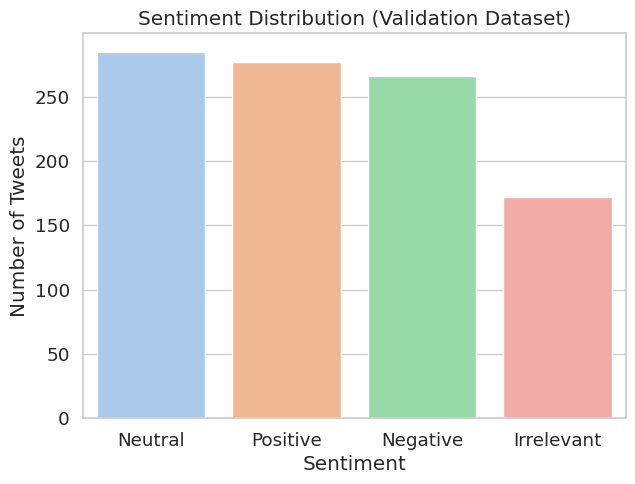

✅ Validation sentiment trend visualized.


In [16]:
# =========================================
# CELL 10: Optional - Validate Trends Using Validation File
# =========================================

valid_df.dropna(subset=['Tweet', 'Entity', 'Sentiment'], inplace=True)
valid_df['Clean_Tweet'] = valid_df['Tweet'].apply(clean_text)

plt.figure(figsize=(7,5))
sns.countplot(data=valid_df, x='Sentiment', order=valid_df['Sentiment'].value_counts().index, palette='pastel')
plt.title("Sentiment Distribution (Validation Dataset)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

print("✅ Validation sentiment trend visualized.")


In [17]:
# =========================================
# CELL 11: Summary Insights
# =========================================

print("🔹 TOTAL TWEETS ANALYZED:", len(train_df))
print("🔹 DISTINCT ENTITIES (Brands/Topics):", train_df['Entity'].nunique())
print("\n🔹 Quick Insights:")
print("- Positive and Negative sentiments reveal overall public mood.")
print("- Top entities highlight most discussed brands.")
print("- WordClouds and bigrams show common language patterns.")
print("- Validation dataset confirms similar sentiment distribution trends.")
print("\n✅ Sentiment analysis and visualization completed successfully!")


🔹 TOTAL TWEETS ANALYZED: 73996
🔹 DISTINCT ENTITIES (Brands/Topics): 32

🔹 Quick Insights:
- Positive and Negative sentiments reveal overall public mood.
- Top entities highlight most discussed brands.
- WordClouds and bigrams show common language patterns.
- Validation dataset confirms similar sentiment distribution trends.

✅ Sentiment analysis and visualization completed successfully!
